In [1]:
import numpy as np
from scipy.special import hankel1
from scipy.linalg import solve
from numpy.polynomial.legendre import leggauss
from joblib import Parallel, delayed


# ============================================================
# PARÁMETROS
# ============================================================

N = 50
k = 10.0

theta_inc = np.pi / 4

d = np.array([
    np.cos(theta_inc),
    np.sin(theta_inc)
])


# ============================================================
# NODOS CHEBYSHEV-LOBATTO
# ============================================================

x = np.cos(np.pi * np.arange(N + 1) / N)

M1 = N + 1
M = M1**2

nodes = np.array([
    (xi, yi)
    for xi in x
    for yi in x
])


# ============================================================
# ONDA INCIDENTE
# ============================================================

def u_inc(x, y):

    return np.exp(
        1j * k * (
            d[0] * x +
            d[1] * y
        )
    )


# ============================================================
# MEDIO
# ============================================================

def m(x, y):

    return (
        (x**2 - 1.0) *
        (y**2 - 1.0)
    )


# ============================================================
# GREEN DE HELMHOLTZ 2D
#
# Phi(rho) = i/4 H_0^(1)(k rho)
#
# Para rho pequeño usamos:
#
# H_0^(1)(z) ~
# 1 + (2i/pi)[ln(z/2) + gamma]
#
# ============================================================

gamma = 0.5772156649015329

rho_switch = 1e-8


def Phi_rho(rho):

    rho = np.asarray(rho)

    result = np.empty(
        rho.shape,
        dtype=complex
    )

    small = rho < rho_switch
    normal = ~small

    # --------------------------------------------------------
    # Región normal
    # --------------------------------------------------------

    if np.any(normal):

        result[normal] = (
            1j / 4
            * hankel1(
                0,
                k * rho[normal]
            )
        )

    # --------------------------------------------------------
    # Región cercana a la singularidad
    #
    # i/4 H0^(1)(kr)
    #
    # ~ -1/(2pi)[ln(kr/2)+gamma] + i/4
    # --------------------------------------------------------

    if np.any(small):

        r = rho[small]

        result[small] = (
            -1.0 / (2.0 * np.pi)
            * (
                np.log(k * r / 2.0)
                + gamma
            )
            + 1j / 4.0
        )

    return result


# ============================================================
# GAUSS-LEGENDRE
# ============================================================

Nt = 18
Ntheta = 36

gt, wt = leggauss(Nt)
gtheta, wtheta = leggauss(Ntheta)


# theta: [-1,1] -> [0,2*pi]

theta_nodes = np.pi * (
    gtheta + 1.0
)

theta_weights = np.pi * wtheta

cos_theta = np.cos(theta_nodes)
sin_theta = np.sin(theta_nodes)


# ============================================================
# LAGRANGE
#
# Usamos una matriz de Vandermonde.
# ============================================================

V = np.vander(
    x,
    N + 1,
    increasing=True
)

Vinv = np.linalg.inv(V)


def lagrange_matrix(z):

    z = np.asarray(z)

    powers = np.vander(
        z,
        N + 1,
        increasing=True
    )

    return powers @ Vinv


# ============================================================
# RADIO MÁXIMO
#
# Distancia desde (xi,yi) hasta el borde del cuadrado
# siguiendo la dirección theta.
# ============================================================

def rmax_vectorized(xi, yi):

    c = cos_theta
    s = sin_theta

    r = np.full(
        Ntheta,
        np.inf,
        dtype=float
    )

    # --------------------------------------------------------
    # x = 1
    # --------------------------------------------------------

    mask = c > 1e-14

    r[mask] = np.minimum(
        r[mask],
        (1.0 - xi) / c[mask]
    )

    # --------------------------------------------------------
    # x = -1
    # --------------------------------------------------------

    mask = c < -1e-14

    r[mask] = np.minimum(
        r[mask],
        (-1.0 - xi) / c[mask]
    )

    # --------------------------------------------------------
    # y = 1
    # --------------------------------------------------------

    mask = s > 1e-14

    r[mask] = np.minimum(
        r[mask],
        (1.0 - yi) / s[mask]
    )

    # --------------------------------------------------------
    # y = -1
    # --------------------------------------------------------

    mask = s < -1e-14

    r[mask] = np.minimum(
        r[mask],
        (-1.0 - yi) / s[mask]
    )

    return r


# ============================================================
# UNA FILA COMPLETA DE A
#
# Coordenadas:
#
#   x' = xi + rho cos(theta)
#   y' = yi + rho sin(theta)
#
# Cambio radial:
#
#   rho = t^2
#
# Entonces:
#
#   d rho = 2t dt
#
# y el Jacobiano polar:
#
#   rho d rho = 2t^3 dt
# ============================================================

def compute_A_row(index):

    xi, yi = nodes[index]

    row = np.zeros(
        M,
        dtype=complex
    )

    # --------------------------------------------------------
    # Radios máximos
    # --------------------------------------------------------

    rho_max = rmax_vectorized(
        xi,
        yi
    )

    t_max = np.sqrt(
        rho_max
    )

    # --------------------------------------------------------
    # Integración sobre theta
    # --------------------------------------------------------

    for l in range(Ntheta):

        tm = t_max[l]

        # Seguridad numérica
        if not np.isfinite(tm) or tm <= 1e-14:
            continue

        c = cos_theta[l]
        s = sin_theta[l]

        # ----------------------------------------------------
        # Gauss en [0,tm]
        # ----------------------------------------------------

        t = 0.5 * tm * (
            gt + 1.0
        )

        wt_radial = 0.5 * tm * wt

        # ----------------------------------------------------
        # rho = t^2
        # ----------------------------------------------------

        rho = t**2

        # ----------------------------------------------------
        # Coordenadas físicas
        # ----------------------------------------------------

        xp = xi + rho * c
        yp = yi + rho * s

        # ----------------------------------------------------
        # Green
        # ----------------------------------------------------

        phi = Phi_rho(rho)

        # ----------------------------------------------------
        # Medio
        # ----------------------------------------------------

        factor = (
            phi *
            m(xp, yp)
        )

        # ----------------------------------------------------
        # Lagrange
        #
        # Lx:
        #
        # Nt x (N+1)
        #
        # Ly:
        #
        # Nt x (N+1)
        # ----------------------------------------------------

        Lx = lagrange_matrix(xp)
        Ly = lagrange_matrix(yp)

        # ----------------------------------------------------
        # Jacobiano
        #
        # rho d rho = 2t^3 dt
        # ----------------------------------------------------

        jacobian = 2.0 * t**3

        # ----------------------------------------------------
        # Pesos completos
        # ----------------------------------------------------

        weighted = (
            factor *
            jacobian *
            wt_radial
        )

        # ----------------------------------------------------
        # Integral radial:
        #
        # A_pq =
        #
        # integral weighted *
        # L_p(xp) *
        # L_q(yp)
        #
        # ----------------------------------------------------

        contribution = np.einsum(
            'r,rp,rq->pq',
            weighted,
            Lx,
            Ly,
            optimize=True
        )

        # ----------------------------------------------------
        # Peso angular
        # ----------------------------------------------------

        contribution *= theta_weights[l]

        # ----------------------------------------------------
        # Añadir a la fila
        # ----------------------------------------------------

        row += contribution.ravel()

    return row


# ============================================================
# CONSTRUCCIÓN DE A
# ============================================================

print(
    f"Construyendo A\n"
    f"N = {N}\n"
    f"M = {M}\n"
    f"Gauss radial = {Nt}\n"
    f"Gauss angular = {Ntheta}\n"
)

# ------------------------------------------------------------
# Paralelización
# ------------------------------------------------------------

rows = Parallel(
    n_jobs=-1,
    verbose=10
)(
    delayed(compute_A_row)(i)
    for i in range(M)
)

A = np.asarray(
    rows,
    dtype=complex
)


# ============================================================
# COMPROBACIÓN NUMÉRICA
# ============================================================

print()
print("Comprobando A...")

n_nan = np.isnan(A).sum()
n_inf = np.isinf(A).sum()

print("NaN en A:", n_nan)
print("Inf en A:", n_inf)

if n_nan > 0 or n_inf > 0:

    print()
    print("ERROR: A contiene NaN o Inf.")

    raise ValueError(
        "La matriz A contiene NaN/Inf."
    )

print(
    "max |A_ij| =",
    np.max(np.abs(A))
)


# ============================================================
# TÉRMINO INCIDENTE
# ============================================================

F = np.array([
    u_inc(xi, yi)
    for xi, yi in nodes
])


# ============================================================
# COMPROBAR F
# ============================================================

print(
    "NaN en F:",
    np.isnan(F).sum()
)

print(
    "Inf en F:",
    np.isinf(F).sum()
)


# ============================================================
# RESOLVER
#
#     (I - A) U = F
# ============================================================

print()
print("Resolviendo sistema...")

U = solve(
    np.eye(
        M,
        dtype=complex
    ) - A,
    F
)

print("Cálculo terminado.")


Construyendo A
N = 50
M = 2601
Gauss radial = 18
Gauss angular = 36



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19488246495039246s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.10743880271911621s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.16129159927368164s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18526101112365723s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 186 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Batch computation too slow (2.1297360607879643s.) Setting batch_size=2.
[Parallel(


Comprobando A...
NaN en A: 0
Inf en A: 0
max |A_ij| = 0.013336591908075315
NaN en F: 0
Inf en F: 0

Resolviendo sistema...
Cálculo terminado.


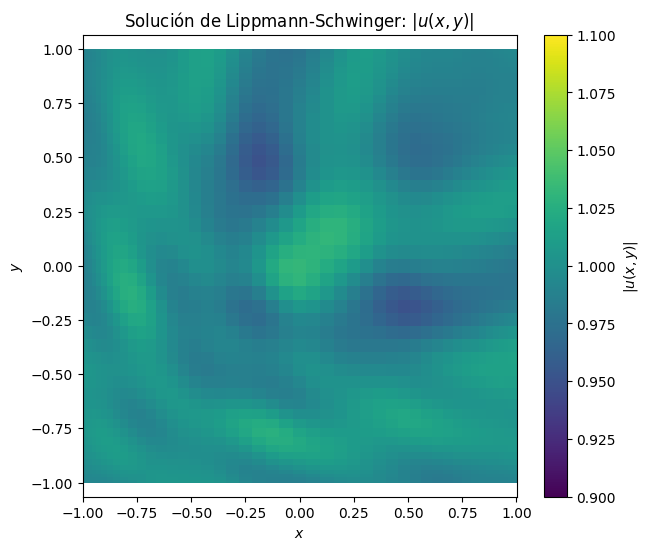

In [2]:
import matplotlib.pyplot as plt

U_grid = U.reshape((N + 1, N + 1))

X, Y = np.meshgrid(x, x, indexing='ij')

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    X,
    Y,
    np.abs(U_grid),
    shading='auto',
    cmap='viridis',
    vmin=0.9,
    vmax=1.1
)

plt.colorbar(label=r'$|u(x,y)|$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Solución de Lippmann-Schwinger: $|u(x,y)|$')

plt.axis('equal')
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hankel1


# ============================================================
# DOMINIO DE OBSERVACIÓN
# ============================================================

L = 3.0

Nx_plot = 300
Ny_plot = 300

x_plot = np.linspace(-L, L, Nx_plot)
y_plot = np.linspace(-L, L, Ny_plot)

X_plot, Y_plot = np.meshgrid(
    x_plot,
    y_plot,
    indexing='ij'
)


# ============================================================
# NODOS DE INTEGRACIÓN SOBRE EL OBSTÁCULO
#
# Clenshaw-Curtis con pesos de Waldvogel
#
# Usamos los mismos nodos Chebyshev-Lobatto que ya tienes:
#
#       x_j = cos(pi*j/N)
#
# ============================================================

def clenshaw_curtis_waldvogel(N):

    theta = np.pi * np.arange(N + 1) / N

    w = np.zeros(N + 1)

    if N == 1:
        return np.array([-1.0, 1.0]), np.array([1.0, 1.0])

    # --------------------------------------------------------
    # Nodos
    # --------------------------------------------------------

    x_cc = np.cos(theta)

    # --------------------------------------------------------
    # Caso N par
    # --------------------------------------------------------

    if N % 2 == 0:

        w[0] = 1.0 / (N**2 - 1.0)
        w[-1] = w[0]

        ii = np.arange(1, N)

        v = np.ones(N - 1)

        v -= np.cos(N * theta[ii]) / (N**2 - 1.0)

        for k_mode in range(1, N // 2):

            v -= (
                2.0
                * np.cos(2.0 * k_mode * theta[ii])
                / (4.0 * k_mode**2 - 1.0)
            )

        w[ii] = 2.0 * v / N

    # --------------------------------------------------------
    # Caso N impar
    # --------------------------------------------------------

    else:

        w[0] = 1.0 / N**2
        w[-1] = w[0]

        ii = np.arange(1, N)

        v = np.ones(N - 1)

        v -= np.cos(N * theta[ii]) / N**2

        for k_mode in range(1, (N - 1) // 2 + 1):

            v -= (
                2.0
                * np.cos(2.0 * k_mode * theta[ii])
                / (4.0 * k_mode**2 - 1.0)
            )

        w[ii] = 2.0 * v / N

    return x_cc, w


# ============================================================
# Nodos y pesos de Clenshaw-Curtis
# ============================================================

x_cc, w_cc = clenshaw_curtis_waldvogel(N)


# ============================================================
# Comprobación de los pesos
#
# La integral de 1 sobre [-1,1] debe ser 2.
# ============================================================

print(
    "Integral CC de 1 =",
    np.sum(w_cc)
)


# ============================================================
# Nodos 2D del obstáculo
# ============================================================

X_src, Y_src = np.meshgrid(
    x_cc,
    x_cc,
    indexing='ij'
)


# ============================================================
# Solución U sobre los nodos de Chebyshev
#
# El orden de nodes era:
#
# for xi in x:
#     for yi in x:
#
# por tanto:
#
# U.reshape(N+1,N+1)
# ============================================================

U_grid = U.reshape(
    (N + 1, N + 1)
)


# ============================================================
# m(x',y') * u(x',y')
# ============================================================

MU = (
    (X_src**2 - 1.0)
    * (Y_src**2 - 1.0)
    * U_grid
)


# ============================================================
# Pesos 2D
# ============================================================

W2 = np.outer(
    w_cc,
    w_cc
)


# ============================================================
# Fuente efectiva
# ============================================================

SOURCE = (
    W2 * MU
).ravel()

X_SRC = X_src.ravel()
Y_SRC = Y_src.ravel()


# ============================================================
# GREEN DE HELMHOLTZ
#
# Aquí evaluamos la solución FUERA del obstáculo.
#
# Si algún punto de observación cae exactamente sobre un nodo
# fuente, rho=0. Lo tratamos por seguridad.
# ============================================================

def Phi_field(rho):

    result = np.empty_like(
        rho,
        dtype=complex
    )

    mask = rho > 1e-14

    result[mask] = (
        1j / 4.0
        * hankel1(
            0,
            k * rho[mask]
        )
    )

    # Para rho=0:
    #
    # La Green es singular.
    #
    # No queremos usar este procedimiento para evaluar
    # directamente sobre un punto fuente.
    #
    result[~mask] = 0.0

    return result


# ============================================================
# ONDA INCIDENTE EN TODO EL DOMINIO
# ============================================================

U_inc_plot = u_inc(
    X_plot,
    Y_plot
)


# ============================================================
# CAMPO DISPERSADO
#
# Hacemos la integral por bloques para controlar memoria.
# ============================================================

X_obs = X_plot.ravel()
Y_obs = Y_plot.ravel()

n_obs = len(X_obs)

U_scat = np.zeros(
    n_obs,
    dtype=complex
)


# Tamaño del bloque
block_size = 500

print()
print(
    f"Evaluando campo en {n_obs} puntos..."
)


for start in range(
    0,
    n_obs,
    block_size
):

    end = min(
        start + block_size,
        n_obs
    )

    xo = X_obs[start:end]
    yo = Y_obs[start:end]

    # --------------------------------------------------------
    # Distancias:
    #
    # shape:
    #
    # (block_size, M)
    # --------------------------------------------------------

    dx = (
        xo[:, None]
        - X_SRC[None, :]
    )

    dy = (
        yo[:, None]
        - Y_SRC[None, :]
    )

    rho = np.sqrt(
        dx**2 + dy**2
    )

    # --------------------------------------------------------
    # Green
    # --------------------------------------------------------

    Phi = Phi_field(rho)

    # --------------------------------------------------------
    # Integral
    #
    # u_scat =
    #
    # sum_j Phi_j * m_j * u_j * w_j
    # --------------------------------------------------------

    U_scat[start:end] = (
        Phi @ SOURCE
    )

    # --------------------------------------------------------
    # Progreso
    # --------------------------------------------------------

    if (
        start == 0
        or (start // block_size) % 10 == 0
    ):

        print(
            f"{end:7d}/{n_obs}"
            f"  ({100*end/n_obs:6.2f} %)"
        )


# ============================================================
# SOLUCIÓN TOTAL
# ============================================================

U_plot = (
    U_inc_plot.ravel()
    + U_scat
)

U_plot = U_plot.reshape(
    X_plot.shape
)


# ============================================================
# RESULTADOS
# ============================================================

print()
print("Evaluación terminada.")

print(
    "max |u| =",
    np.max(np.abs(U_plot))
)

print(
    "min |u| =",
    np.min(np.abs(U_plot))
)


Integral CC de 1 = 2.0000000000000004

Evaluando campo en 90000 puntos...
    500/90000  (  0.56 %)
   5500/90000  (  6.11 %)
  10500/90000  ( 11.67 %)
  15500/90000  ( 17.22 %)
  20500/90000  ( 22.78 %)
  25500/90000  ( 28.33 %)
  30500/90000  ( 33.89 %)
  35500/90000  ( 39.44 %)
  40500/90000  ( 45.00 %)
  45500/90000  ( 50.56 %)
  50500/90000  ( 56.11 %)
  55500/90000  ( 61.67 %)
  60500/90000  ( 67.22 %)
  65500/90000  ( 72.78 %)
  70500/90000  ( 78.33 %)
  75500/90000  ( 83.89 %)
  80500/90000  ( 89.44 %)
  85500/90000  ( 95.00 %)

Evaluación terminada.
max |u| = 1.0283022281798107
min |u| = 0.9835711257747729


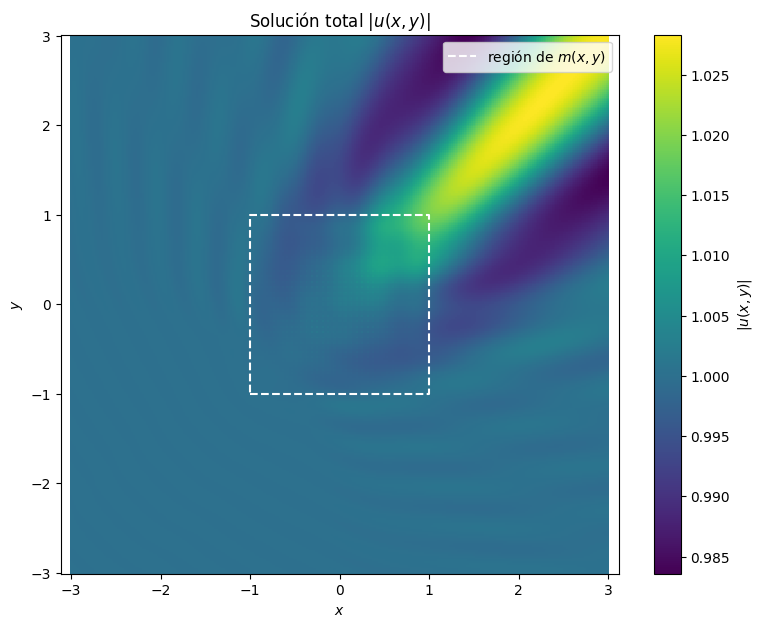

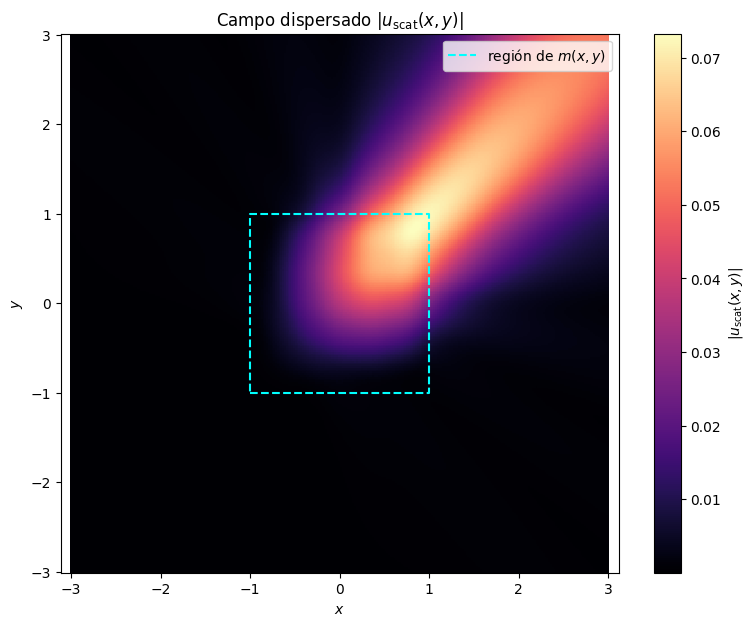

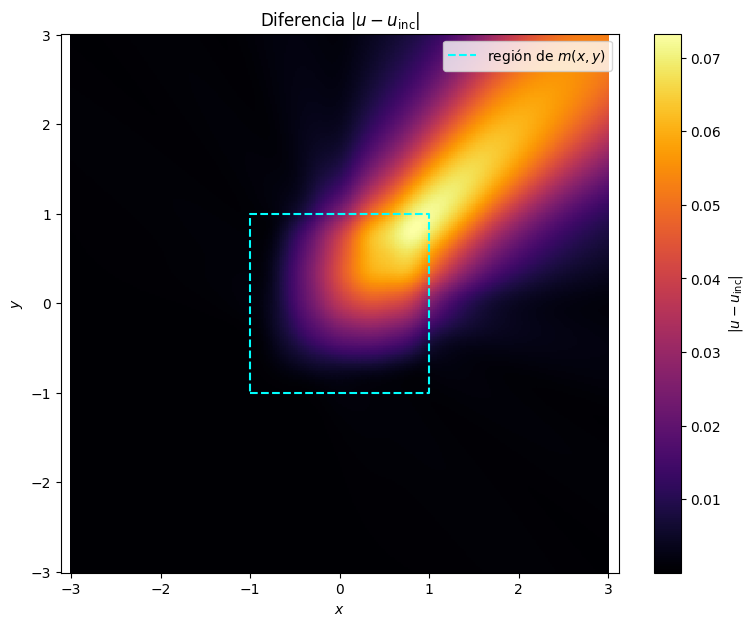

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# MÓDULO DE LA SOLUCIÓN TOTAL
# ============================================================

abs_U = np.abs(U_plot)


plt.figure(figsize=(9, 7))

plt.pcolormesh(
    X_plot,
    Y_plot,
    abs_U,
    shading='auto',
    cmap='viridis'
)

plt.colorbar(
    label=r'$|u(x,y)|$'
)

# Borde del dominio donde está m
plt.plot(
    [-1, 1, 1, -1, -1],
    [-1, -1, 1, 1, -1],
    '--',
    color='white',
    linewidth=1.5,
    label='región de $m(x,y)$'
)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.title(
    r'Solución total $|u(x,y)|$'
)

plt.axis('equal')
plt.legend()

plt.show()


# ============================================================
# CAMPO DISPERSADO
# ============================================================

U_scat_plot = (
    U_plot - U_inc_plot
)

abs_scat = np.abs(
    U_scat_plot
)


plt.figure(figsize=(9, 7))

plt.pcolormesh(
    X_plot,
    Y_plot,
    abs_scat,
    shading='auto',
    cmap='magma'
)

plt.colorbar(
    label=r'$|u_{\mathrm{scat}}(x,y)|$'
)

plt.plot(
    [-1, 1, 1, -1, -1],
    [-1, -1, 1, 1, -1],
    '--',
    color='cyan',
    linewidth=1.5,
    label='región de $m(x,y)$'
)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.title(
    r'Campo dispersado $|u_{\mathrm{scat}}(x,y)|$'
)

plt.axis('equal')
plt.legend()

plt.show()


# ============================================================
# DIFERENCIA RESPECTO DE LA ONDA INCIDENTE
# ============================================================

difference = np.abs(
    U_plot - U_inc_plot
)


plt.figure(figsize=(9, 7))

plt.pcolormesh(
    X_plot,
    Y_plot,
    difference,
    shading='auto',
    cmap='inferno'
)

plt.colorbar(
    label=r'$|u-u_{\mathrm{inc}}|$'
)

plt.plot(
    [-1, 1, 1, -1, -1],
    [-1, -1, 1, 1, -1],
    '--',
    color='cyan',
    linewidth=1.5,
    label='región de $m(x,y)$'
)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.title(
    r'Diferencia $|u-u_{\mathrm{inc}}|$'
)

plt.axis('equal')
plt.legend()

plt.show()


### Guardar / Cargar los datos

In [5]:
# ============================================================
# GUARDAR DATOS PARA EL PROBLEMA INVERSO
# ============================================================
np.savez('datos_inversion.npz',
         U_plot=U_plot,
         U_inc_plot=U_inc_plot,
         X_plot=X_plot,
         Y_plot=Y_plot)

print("¡Datos guardados exitosamente en 'datos_inversion.npz'!")

¡Datos guardados exitosamente en 'datos_inversion.npz'!


In [ ]:
import numpy as np

# Cargar los datos guardados
data = np.load('datos_inversion.npz')

U_plot = data['U_plot']
U_inc_plot = data['U_inc_plot']
X_plot = data['X_plot']
Y_plot = data['Y_plot']

# A partir de aquí ya puedes calcular el campo dispersado exacto y usarlo en tu solver:
U_scat_plot = U_plot - U_inc_plot